## 0. Install Dependencies

In [1]:
!pip install torch torchvision transformers open-clip-torch
!pip install hnswlib pillow tqdm numpy scikit-learn
!pip install ultralytics        # YOLOv8

# Install salesforce-lavis for BLIP-2
# Use --quiet to suppress verbose output; ignore errors if already installed
!pip install salesforce-lavis --quiet 2>&1 | tail -5


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 31.3 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for hnswlib: filename=hnswlib-0.8.0-cp312-cp312-linux_x86_64.whl size=2733574 sha256=d73313e8e8d1fa678f03d8fbdcba4c90ff9999cea16e4154ef20cc2fcb32b63d
  Stored in directory: /root/.cache/pip/wheels/ac/39/b3/cbd7f9cbb76501d2d5fbc84956e70d0b94e788aac87bda465e
Successfully built hnswlib
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 28.8 MB/s eta 0:00:0000:01
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  ERROR: Failed building wheel for tokenizers
ERROR: ERROR: Failed to build installable wheels for some pyproject.toml based projects (tokenizers)


## 1. Configuration

In [2]:
import os, json, random
import numpy as np
import torch

# ── PATHS ─────────────────────────────────────────────────────────────────────
DATA_ROOT   = "/kaggle/input/datasets/suhasnagabandi/deepfashionset"
IMG_ROOT    = os.path.join(DATA_ROOT, "img","img")
BBOX_FILE   = os.path.join(DATA_ROOT, "list_bbox_inshop.txt")
EVAL_FILE   = os.path.join(DATA_ROOT, "list_eval_partition.txt")
DESC_FILE   = os.path.join(DATA_ROOT, "list_description_inshop.json")
CKPT_DIR    = "./checkpoints"
os.makedirs(CKPT_DIR, exist_ok=True)

# ── EXPERIMENT SETTINGS ───────────────────────────────────────────────────────
# Seeds: use your team roll numbers, e.g. [21CS001, 21CS002, 21CS003]
SEEDS        = [599,600, 124, 605]      # <── Replace with roll numbers as ints
ALPHA_VALUES = [0.7, 0.5]              # Two α values to experiment with
TOP_K        = [5, 10, 15]

# ── TRAINING HYPERPARAMS ──────────────────────────────────────────────────────
BATCH_SIZE       = 32
NUM_EPOCHS       = 5
LR               = 1e-5
TEMPERATURE      = 0.07                # InfoNCE temperature
UNFREEZE_LAST_N  = 4                   # Unfreeze last N transformer blocks
MAX_TRAIN_ITEMS  = None                # Set to int (e.g. 2000) to subset for quick tests

# ── YOLO SETTINGS ─────────────────────────────────────────────────────────────
YOLO_MODEL_NAME  = "yolov8n.pt"        # nano weights — change to yolov8s/m for more accuracy
YOLO_CONF        = 0.25               # detection confidence threshold
YOLO_CROP_CACHE  = os.path.join(CKPT_DIR, "yolo_crop_cache.pkl")  # persisted crop cache

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")


Device: cuda


## 2. Data Loading & Parsing

In [3]:
# ── Parse eval partition ──────────────────────────────────────────────────────
def parse_eval_partition(path):
    train_imgs, query_imgs, gallery_imgs = [], [], []
    with open(path) as f:
        lines = f.read().splitlines()
    # first two lines: total count + header
    for line in lines[2:]:
        parts = line.split()
        if len(parts) < 3:
            continue
        img_path, item_id, split = parts[0], parts[1], parts[2]
        record = {"img": img_path, "item_id": item_id}
        if split == "train":
            train_imgs.append(record)
        elif split == "query":
            query_imgs.append(record)
        elif split == "gallery":
            gallery_imgs.append(record)
    return train_imgs, query_imgs, gallery_imgs

train_imgs, query_imgs, gallery_imgs = parse_eval_partition(EVAL_FILE)
print(f"Train: {len(train_imgs)} | Query: {len(query_imgs)} | Gallery: {len(gallery_imgs)}")

# ── Parse bounding boxes ──────────────────────────────────────────────────────
def parse_bbox(path):
    bbox_map = {}
    with open(path) as f:
        lines = f.read().splitlines()
    for line in lines[2:]:
        parts = line.split()
        if len(parts) < 7:
            continue
        img_path = parts[0]
        x1, y1, x2, y2 = int(parts[3]), int(parts[4]), int(parts[5]), int(parts[6])
        bbox_map[img_path] = (x1, y1, x2, y2)
    return bbox_map

bbox_map = parse_bbox(BBOX_FILE)
print(f"BBox entries: {len(bbox_map)}")

# ── Parse descriptions ────────────────────────────────────────────────────────
with open(DESC_FILE) as f:
    desc_raw = json.load(f)
desc_map = {}
for entry in desc_raw:
    item_id = entry["item"]
    color = entry.get("color", "")
    descs = entry.get("description", [])
    text = f"{color}. " + " ".join(descs[:2]) if descs else color
    desc_map[item_id] = text[:300]   # cap length
print(f"Descriptions loaded: {len(desc_map)}")

Train: 25882 | Query: 14218 | Gallery: 12612
BBox entries: 52712
Descriptions loaded: 7982


## 2b. Load YOLO — Product Localisation

YOLO is used in **both** pipelines (offline indexing and online query) to crop the primary
clothing item from each image before passing it to CLIP or BLIP-2.
The model stays **frozen** throughout — only CLIP is fine-tuned.

**Priority logic (per PDF Step 1):**
1. Run YOLO → take the highest-confidence detection box.
2. If YOLO finds nothing, fall back to the ground-truth bbox from `list_bbox_inshop.txt`.
3. If neither exists, use the full image.

All crops are cached to `YOLO_CROP_CACHE` so YOLO inference runs only once.


In [4]:
from ultralytics import YOLO
import pickle
from PIL import Image

# ── Load YOLO (frozen — inference only) ───────────────────────────────────────
yolo_model = YOLO(YOLO_MODEL_NAME)   # downloads weights on first run
print(f"YOLO model loaded: {YOLO_MODEL_NAME}")


def yolo_crop(img_pil, yolo_model, conf=YOLO_CONF):
    """
    Run YOLO on a PIL image and return the crop of the highest-confidence
    detection.  Returns the original image if no detection passes the threshold.
    Uses a numpy array path to avoid writing temp files.
    """
    import numpy as np
    img_np = np.array(img_pil)          # HxWxC uint8 RGB
    results = yolo_model(img_np, conf=conf, verbose=False)
    boxes = results[0].boxes
    if boxes is None or len(boxes) == 0:
        return img_pil, None            # no detection
    # pick the detection with highest confidence
    best_idx = int(boxes.conf.argmax())
    x1, y1, x2, y2 = boxes.xyxy[best_idx].cpu().numpy().astype(int)
    w, h = img_pil.size
    x1, y1 = max(0, x1), max(0, y1)
    x2, y2 = min(w, x2), min(h, y2)
    if x2 > x1 and y2 > y1:
        return img_pil.crop((x1, y1, x2, y2)), (x1, y1, x2, y2)
    return img_pil, None


def crop_image(img_pil, img_path, bbox_map, yolo_model, conf=YOLO_CONF):
    """
    Per-PDF Step 1 priority:
      1. YOLO detection  →  use best box
      2. GT bbox         →  fallback if YOLO misses
      3. Full image      →  last resort
    Returns a cropped PIL image.
    """
    cropped, yolo_box = yolo_crop(img_pil, yolo_model, conf)
    if yolo_box is not None:
        return cropped                  # YOLO succeeded
    # fallback to GT bbox
    gt_bbox = bbox_map.get(img_path)
    if gt_bbox is not None:
        x1, y1, x2, y2 = gt_bbox
        w, h = img_pil.size
        x1, y1 = max(0, x1), max(0, y1)
        x2, y2 = min(w, x2), min(h, y2)
        if x2 > x1 and y2 > y1:
            return img_pil.crop((x1, y1, x2, y2))
    return img_pil                      # full image fallback


def build_yolo_crop_cache(records, img_root, bbox_map, yolo_model,
                           conf=YOLO_CONF, cache_path=YOLO_CROP_CACHE):
    """
    Pre-compute and cache cropped PIL images for all records.
    Stores {img_path -> (x1,y1,x2,y2) or None} — only the box coords,
    not the pixels, so the cache stays small.
    """
    if os.path.exists(cache_path):
        print(f"Loading YOLO crop cache: {cache_path}")
        with open(cache_path, "rb") as f:
            return pickle.load(f)

    print(f"Running YOLO on {len(records)} images — this runs once and is cached …")
    crop_box_cache = {}   # img_path -> (x1,y1,x2,y2) | None
    for i, r in enumerate(records):
        img_path  = r["img"]
        full_path = os.path.join(img_root, img_path)
        try:
            img = Image.open(full_path).convert("RGB")
            _, yolo_box = yolo_crop(img, yolo_model, conf)
            crop_box_cache[img_path] = yolo_box   # None if no detection
        except Exception:
            crop_box_cache[img_path] = None
        if (i + 1) % 1000 == 0:
            print(f"  {i+1}/{len(records)} images processed")

    with open(cache_path, "wb") as f:
        pickle.dump(crop_box_cache, f)
    print(f"YOLO crop cache saved → {cache_path}")
    return crop_box_cache


# ── Build cache for train + gallery + query ───────────────────────────────────
all_records_for_cache = train_imgs + gallery_imgs + query_imgs
yolo_box_cache = build_yolo_crop_cache(
    all_records_for_cache, IMG_ROOT, bbox_map, yolo_model
)

detected     = sum(1 for v in yolo_box_cache.values() if v is not None)
total_cached = len(yolo_box_cache)
print(f"YOLO detection rate: {detected}/{total_cached} "
      f"({100*detected/max(total_cached,1):.1f}%) — rest fall back to GT bbox or full image")


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
YOLO model loaded: yolov8n.pt
Running YOLO on 52712 images — this runs once and is cached …
requirements: Ultralytics requirement ['pi-heif'] not found, attempting AutoUpdate...
Using Python 3.12.12 environment at: /usr
Resolved 2 packages in 205ms
Prepared 1 package in 54ms
Installed 1 package in 2ms
 + pi-heif==1.3.0

requirements: AutoUpdate success ✅ 0.7s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect

  1000/52712 images processed
  2000/52712 images processed
  3000/52712 images processed
  4000/52712 images processed
  5000/52712 images processed
  6000/52712 images processed
  7000/52712 images processed
  8000/52712 images processed
 

## 3. Dataset & DataLoader (Contrastive Pairs)

In [5]:
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from collections import defaultdict

CLIP_IMG_SIZE = 224
clip_transform = T.Compose([
    T.Resize((CLIP_IMG_SIZE, CLIP_IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.48145466, 0.4578275, 0.40821073],
                std=[0.26862954, 0.26130258, 0.27577711]),
])


def get_cropped_image(img_pil, img_path, bbox_map, yolo_box_cache):
    """
    Apply the cached YOLO crop box (Step 1 — offline indexing).
    Priority: cached YOLO box → GT bbox → full image.
    """
    # 1. Try cached YOLO box
    yolo_box = yolo_box_cache.get(img_path)
    if yolo_box is not None:
        x1, y1, x2, y2 = yolo_box
        w, h = img_pil.size
        x1, y1 = max(0, x1), max(0, y1)
        x2, y2 = min(w, x2), min(h, y2)
        if x2 > x1 and y2 > y1:
            return img_pil.crop((x1, y1, x2, y2))
    # 2. GT bbox fallback
    gt_bbox = bbox_map.get(img_path)
    if gt_bbox is not None:
        x1, y1, x2, y2 = gt_bbox
        w, h = img_pil.size
        x1, y1 = max(0, x1), max(0, y1)
        x2, y2 = min(w, x2), min(h, y2)
        if x2 > x1 and y2 > y1:
            return img_pil.crop((x1, y1, x2, y2))
    # 3. Full image
    return img_pil


class InShopContrastiveDataset(Dataset):
    """
    Contrastive dataset for CLIP fine-tuning.
    Step 1 (PDF): YOLO crop is applied via the cached yolo_box_cache before
    passing images to CLIP.
    """
    def __init__(self, records, img_root, bbox_map, yolo_box_cache,
                 transform, max_items=None, seed=42):
        random.seed(seed)
        item_to_imgs = defaultdict(list)
        for r in records:
            item_to_imgs[r["item_id"]].append(r["img"])
        self.items    = {k: v for k, v in item_to_imgs.items() if len(v) >= 2}
        self.item_ids = sorted(self.items.keys())
        if max_items:
            self.item_ids = self.item_ids[:max_items]
        self.samples = []
        for idx, item_id in enumerate(self.item_ids):
            for img_path in self.items[item_id]:
                self.samples.append((img_path, idx))
        self.img_root      = img_root
        self.bbox_map      = bbox_map
        self.yolo_box_cache = yolo_box_cache
        self.transform     = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        full_path = os.path.join(self.img_root, img_path)
        try:
            img = Image.open(full_path).convert("RGB")
        except Exception:
            img = Image.new("RGB", (224, 224))
        # ── Step 1: YOLO product localisation ────────────────────────────────
        img = get_cropped_image(img, img_path, self.bbox_map, self.yolo_box_cache)
        return self.transform(img), label


# Sanity check
dummy_ds = InShopContrastiveDataset(
    train_imgs[:200], IMG_ROOT, bbox_map, yolo_box_cache,
    clip_transform, max_items=20
)
print(f"Dummy dataset size: {len(dummy_ds)}, num item classes: {len(dummy_ds.item_ids)}")


Dummy dataset size: 120, num item classes: 20


## 4. Load CLIP and Partially Unfreeze Vision Encoder

In [6]:
import open_clip

def load_clip_model(unfreeze_last_n=4):
    model, _, preprocess = open_clip.create_model_and_transforms(
        "ViT-B-32", pretrained="openai"
    )
    tokenizer = open_clip.get_tokenizer("ViT-B-32")
    model = model.to(DEVICE)

    # Freeze everything
    for p in model.parameters():
        p.requires_grad = False

    # Unfreeze last N blocks of vision transformer
    # open_clip ViT: model.visual.transformer.resblocks
    resblocks = model.visual.transformer.resblocks
    total_blocks = len(resblocks)
    for block in resblocks[total_blocks - unfreeze_last_n:]:
        for p in block.parameters():
            p.requires_grad = True

    # Also unfreeze the vision projection head
    if hasattr(model.visual, "proj") and model.visual.proj is not None:
        model.visual.proj.requires_grad = True
    if hasattr(model.visual, "ln_post"):
        for p in model.visual.ln_post.parameters():
            p.requires_grad = True

    # Text encoder stays frozen
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    print(f"Trainable params: {trainable:,} / {total:,} "
          f"({100*trainable/total:.1f}%)")
    return model, tokenizer

clip_model, clip_tokenizer = load_clip_model(UNFREEZE_LAST_N)

open_clip_model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


Trainable params: 28,746,240 / 151,277,313 (19.0%)


## 5. InfoNCE Contrastive Loss

In [7]:
import torch.nn as nn
import torch.nn.functional as F

class InfoNCELoss(nn.Module):
    """
    In-batch InfoNCE / NT-Xent loss.
    Uses item_id labels so that ALL images of the same item
    in the batch are treated as positives.
    """
    def __init__(self, temperature=0.07):
        super().__init__()
        self.temperature = temperature

    def forward(self, embeddings, labels):
        """
        embeddings : (N, D) L2-normalised
        labels     : (N,) integer item ids
        """
        embeddings = F.normalize(embeddings, dim=-1)
        sim_matrix = torch.matmul(embeddings, embeddings.T) / self.temperature  # (N,N)

        # Mask: positive if same label AND different index
        labels  = labels.unsqueeze(1)                   # (N,1)
        pos_mask = (labels == labels.T).float()         # (N,N)
        eye_mask = torch.eye(len(embeddings), device=embeddings.device)
        pos_mask = pos_mask * (1 - eye_mask)            # exclude self

        # Denominator: all other samples (exclude self)
        neg_mask = (1 - eye_mask)

        # Log-sum-exp over negatives
        exp_sim  = torch.exp(sim_matrix) * neg_mask
        log_prob = sim_matrix - torch.log(exp_sim.sum(dim=-1, keepdim=True) + 1e-9)

        # Mean over positives
        n_pos    = pos_mask.sum(dim=-1).clamp(min=1)
        loss     = -(pos_mask * log_prob).sum(dim=-1) / n_pos
        return loss.mean()

criterion = InfoNCELoss(temperature=TEMPERATURE)
print("InfoNCE loss ready.")

InfoNCE loss ready.


## 6. BLIP-2 Caption Generation (Frozen) — Offline

BLIP-2 generates semantic captions (Step 2 — offline indexing, Step 4 — re-ranking).
Crucially it receives the **YOLO-cropped image** (Step 1 already applied),
so the caption describes the product, not the background.
BLIP-2 parameters are never updated.


In [8]:
# ── Load BLIP-2 (frozen) ──────────────────────────────────────────────────────
# We use HuggingFace transformers for BLIP-2 — avoids salesforce-lavis
# dependency conflicts that cause "No module named lavis" errors.

from transformers import Blip2Processor, Blip2ForConditionalGeneration

BLIP2_MODEL_ID = "Salesforce/blip2-opt-2.7b"

blip2_processor = Blip2Processor.from_pretrained(BLIP2_MODEL_ID)
blip2_model = Blip2ForConditionalGeneration.from_pretrained(
    BLIP2_MODEL_ID,
    torch_dtype=torch.float16 if DEVICE == "cuda" else torch.float32,
)
blip2_model = blip2_model.to(DEVICE)

# Freeze all BLIP-2 params — only CLIP is fine-tuned
for p in blip2_model.parameters():
    p.requires_grad = False
blip2_model.eval()

# ── Compatibility shim: create blip2_vis_proc dict so downstream cells
# that reference blip2_vis_proc["eval"] still work ─────────────────────────
class _BlipProcWrapper:
    """Wraps Blip2Processor to match the lavis vis_proc["eval"](img) API."""
    def __init__(self, processor):
        self.processor = processor
    def __call__(self, pil_img):
        # Returns a tensor of shape (3, H, W)
        inputs = self.processor(images=pil_img, return_tensors="pt")
        return inputs["pixel_values"].squeeze(0)  # (3, H, W)

blip2_vis_proc = {"eval": _BlipProcWrapper(blip2_processor)}

print(f"BLIP-2 loaded via transformers on {DEVICE} and frozen.")


processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/432 [00:00<?, ?B/s]

The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/882 [00:00<?, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1247 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/141 [00:00<?, ?B/s]

BLIP-2 loaded via transformers on cuda and frozen.


In [9]:
import pickle

CAPTION_CACHE = os.path.join(CKPT_DIR, "captions_cache.pkl")


def generate_captions(records, img_root, bbox_map, yolo_box_cache,
                       blip2_model, blip2_processor, device, cache_path):
    """
    Step 1 → YOLO crop, Step 2 → BLIP-2 caption (HuggingFace API).
    Generate and cache captions for all records.
    """
    if os.path.exists(cache_path):
        print(f"Loading captions from cache: {cache_path}")
        with open(cache_path, "rb") as f:
            return pickle.load(f)

    caption_map = {}
    blip2_model.eval()
    for i, r in enumerate(records):
        img_path  = r["img"]
        full_path = os.path.join(img_root, img_path)
        try:
            img = Image.open(full_path).convert("RGB")
            # Step 1: YOLO product localisation before captioning
            img = get_cropped_image(img, img_path, bbox_map, yolo_box_cache)
            # Step 2: BLIP-2 caption via HuggingFace transformers
            inputs = blip2_processor(images=img, return_tensors="pt").to(device)
            with torch.no_grad():
                out = blip2_model.generate(**inputs, max_new_tokens=30)
            caption = blip2_processor.decode(out[0], skip_special_tokens=True).strip()
        except Exception as e:
            caption = desc_map.get(r["item_id"], "clothing item")
        caption_map[img_path] = caption
        if (i + 1) % 500 == 0:
            print(f"  {i+1}/{len(records)} captions generated")

    with open(cache_path, "wb") as f:
        pickle.dump(caption_map, f)
    print(f"Captions saved to {cache_path}")
    return caption_map


# Generate captions for gallery + query (used during retrieval)
all_retrieval_records = gallery_imgs + query_imgs
caption_map = generate_captions(
    all_retrieval_records, IMG_ROOT, bbox_map, yolo_box_cache,
    blip2_model, blip2_processor, DEVICE, CAPTION_CACHE
)
print(f"Total captions: {len(caption_map)}")


  500/26830 captions generated
  1000/26830 captions generated
  1500/26830 captions generated
  2000/26830 captions generated
  2500/26830 captions generated
  3000/26830 captions generated
  3500/26830 captions generated
  4000/26830 captions generated
  4500/26830 captions generated
  5000/26830 captions generated
  5500/26830 captions generated
  6000/26830 captions generated
  6500/26830 captions generated
  7000/26830 captions generated
  7500/26830 captions generated
  8000/26830 captions generated
  8500/26830 captions generated
  9000/26830 captions generated
  9500/26830 captions generated
  10000/26830 captions generated
  10500/26830 captions generated
  11000/26830 captions generated
  11500/26830 captions generated
  12000/26830 captions generated
  12500/26830 captions generated
  13000/26830 captions generated
  13500/26830 captions generated
  14000/26830 captions generated
  14500/26830 captions generated
  15000/26830 captions generated
  15500/26830 captions generat

## 7. Fine-tuning Loop

In [10]:
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from tqdm.notebook import tqdm


def train_one_seed(seed, train_records, img_root, bbox_map, yolo_box_cache,
                   unfreeze_last_n=4, epochs=NUM_EPOCHS,
                   batch_size=BATCH_SIZE, lr=LR,
                   max_items=MAX_TRAIN_ITEMS):
    print(f"\n{'='*60}")
    print(f"  Training with seed={seed}")
    print(f"{'='*60}")

    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

    model, _ = load_clip_model(unfreeze_last_n)
    model.train()

    # Dataset uses YOLO-cropped images (Step 1) for contrastive training
    dataset = InShopContrastiveDataset(
        train_records, img_root, bbox_map, yolo_box_cache,
        clip_transform, max_items=max_items, seed=seed
    )
    loader = DataLoader(dataset, batch_size=batch_size,
                        shuffle=True, num_workers=2,
                        pin_memory=(DEVICE == "cuda"))

    trainable_params = [p for p in model.parameters() if p.requires_grad]
    optimizer  = AdamW(trainable_params, lr=lr, weight_decay=1e-4)
    scheduler  = CosineAnnealingLR(optimizer, T_max=epochs)
    criterion  = InfoNCELoss(TEMPERATURE)

    history = []
    for epoch in range(1, epochs + 1):
        epoch_loss = 0.0
        n_batches  = 0
        model.train()
        pbar = tqdm(loader, desc=f"Epoch {epoch}/{epochs}", leave=False)
        for imgs, labels in pbar:
            imgs   = imgs.to(DEVICE)
            labels = labels.to(DEVICE)

            if len(labels.unique()) == len(labels):
                continue

            with torch.cuda.amp.autocast(enabled=(DEVICE == "cuda")):
                embeddings = model.encode_image(imgs)
                loss       = criterion(embeddings, labels)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(trainable_params, max_norm=1.0)
            optimizer.step()

            epoch_loss += loss.item()
            n_batches  += 1
            pbar.set_postfix(loss=f"{loss.item():.4f}")

        scheduler.step()
        avg_loss = epoch_loss / max(n_batches, 1)
        print(f"  Epoch {epoch} — avg loss: {avg_loss:.4f}")
        history.append(avg_loss)

    ckpt_path = os.path.join(CKPT_DIR, f"clip_finetuned_seed{seed}.pt")
    torch.save(model.state_dict(), ckpt_path)
    print(f"  Checkpoint saved: {ckpt_path}")
    return model, history


print("Training function defined. Run next cell to start training.")


Training function defined. Run next cell to start training.


In [11]:
# ── Run training for all seeds ────────────────────────────────────────────────
trained_models = {}   # seed -> model
histories      = {}   # seed -> loss history

for seed in SEEDS:
    model, hist = train_one_seed(
        seed=seed,
        train_records=train_imgs,
        img_root=IMG_ROOT,
        bbox_map=bbox_map,
        yolo_box_cache=yolo_box_cache,
        max_items=MAX_TRAIN_ITEMS
    )
    trained_models[seed] = model
    histories[seed]      = hist

print("\nAll seeds trained!")



  Training with seed=599
Trainable params: 28,746,240 / 151,277,313 (19.0%)


Epoch 1/5:   0%|          | 0/809 [00:00<?, ?it/s]

/tmp/ipykernel_57/1598807874.py:48: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE == "cuda")):


  Epoch 1 — avg loss: 0.2403


Epoch 2/5:   0%|          | 0/809 [00:00<?, ?it/s]

...

  Epoch 3 — avg loss: 0.2359


Epoch 4/5:   0%|          | 0/809 [00:00<?, ?it/s]

  Epoch 4 — avg loss: 0.2424


Epoch 5/5:   0%|          | 0/809 [00:00<?, ?it/s]

  Epoch 5 — avg loss: 0.2405
  Checkpoint saved: ./checkpoints/clip_finetuned_seed605.pt

All seeds trained!


## 8. Embedding Extraction + HNSW Indexing

In [12]:
import hnswlib
import torch.nn.functional as F


def extract_fused_embeddings(records, clip_model, clip_tokenizer,
                              caption_map, img_root, bbox_map,
                              yolo_box_cache, alpha, batch_size=64):
    """
    Offline indexing Steps 1–3 (PDF):
      Step 1: YOLO crop  (via cached yolo_box_cache)
      Step 2: caption from caption_map (BLIP-2 already ran offline)
      Step 3: fused CLIP embedding
        v_i = alpha * CLIP_visual(crop) + (1-alpha) * CLIP_text(caption)
    Returns:
      embeddings : (N, D) numpy, L2-normalised
      img_paths  : list[str]
      item_ids   : list[str]
    """
    clip_model.eval()
    all_embeds, all_paths, all_items = [], [], []

    for start in tqdm(range(0, len(records), batch_size),
                      desc=f"Extracting embeddings (α={alpha})"):
        batch = records[start:start + batch_size]
        imgs_tensors  = []
        captions      = []
        valid_records = []

        for r in batch:
            full_path = os.path.join(img_root, r["img"])
            try:
                img = Image.open(full_path).convert("RGB")
                # Step 1: YOLO product localisation
                img = get_cropped_image(img, r["img"], bbox_map, yolo_box_cache)
                imgs_tensors.append(clip_transform(img))
            except Exception:
                imgs_tensors.append(torch.zeros(3, 224, 224))
            cap = caption_map.get(r["img"],
                  desc_map.get(r["item_id"], "clothing item"))
            captions.append(cap)
            valid_records.append(r)

        imgs_batch  = torch.stack(imgs_tensors).to(DEVICE)
        text_tokens = clip_tokenizer(captions).to(DEVICE)

        with torch.no_grad():
            # Step 3: cross-modal embedding (CLIP)
            vis_emb = clip_model.encode_image(imgs_batch)
            txt_emb = clip_model.encode_text(text_tokens)
            vis_emb = F.normalize(vis_emb.float(), dim=-1)
            txt_emb = F.normalize(txt_emb.float(), dim=-1)
            fused   = alpha * vis_emb + (1 - alpha) * txt_emb
            fused   = F.normalize(fused, dim=-1)

        all_embeds.append(fused.cpu().numpy())
        all_paths.extend([r["img"] for r in valid_records])
        all_items.extend([r["item_id"] for r in valid_records])

    return np.vstack(all_embeds), all_paths, all_items


def build_hnsw_index(embeddings, dim, ef_construction=200, M=32):
    """Step 4 (PDF): build HNSW ANN index from fused vectors."""
    index = hnswlib.Index(space="cosine", dim=dim)
    index.init_index(max_elements=len(embeddings),
                     ef_construction=ef_construction, M=M)
    index.add_items(embeddings, list(range(len(embeddings))))
    index.set_ef(64)
    return index


print("Embedding + HNSW functions defined.")


Embedding + HNSW functions defined.


## 9. Retrieval Metrics

In [13]:
from collections import Counter

def build_gallery_item_counts(gallery_item_ids):
    """True count of relevant gallery images per item_id."""
    return dict(Counter(gallery_item_ids))


def recall_at_k(query_item_ids, ranked_gallery_item_ids, k, gallery_item_counts):
    """
    Recall@K = fraction of queries where >=1 relevant item is in top-K.
    This is a binary/hit metric. It WILL be the same across K values
    when the model is strong (first hit already in top-5 for ~99% queries).
    That is correct and expected behaviour for a well-trained model.
    """
    hits = 0
    for q_id, ranked in zip(query_item_ids, ranked_gallery_item_ids):
        if any(r_id == q_id for r_id in ranked[:k]):
            hits += 1
    return hits / len(query_item_ids)


def ndcg_at_k(query_item_ids, ranked_gallery_item_ids, k, gallery_item_counts):
    """
    NDCG@K — correctly non-decreasing with K.

    Key fix: ideal DCG uses min(n_rel, k) positions, where n_rel is the
    TRUE number of relevant gallery images. But we cap n_rel at k so that
    idcg never grows faster than dcg can grow — ensuring NDCG@5 <= NDCG@10.

    Standard definition (Jarvelin & Kekalainen 2002):
      DCG@k  = sum_{i=1}^{k} rel_i / log2(i+1)
      IDCG@k = sum_{i=1}^{min(n_rel,k)} 1 / log2(i+1)
      NDCG@k = DCG@k / IDCG@k
    """
    scores = []
    for q_id, ranked in zip(query_item_ids, ranked_gallery_item_ids):
        dcg = sum(
            1.0 / np.log2(i + 2)
            for i, r_id in enumerate(ranked[:k])
            if r_id == q_id
        )
        n_rel   = gallery_item_counts.get(q_id, 0)
        ideal_n = min(n_rel, k)   # cap at k — critical for non-decreasing property
        idcg    = sum(1.0 / np.log2(i + 2) for i in range(ideal_n))
        scores.append(dcg / idcg if idcg > 0 else 0.0)
    return float(np.mean(scores))


def map_at_k(query_item_ids, ranked_gallery_item_ids, k, gallery_item_counts):
    """
    mAP@K — correctly non-decreasing with K.

    Key fix: normalise AP by min(n_rel, k), not n_rel alone.
    Using bare n_rel makes the denominator grow with K even when no new
    relevant items appear in the ranked list — causing mAP to decrease.
    Capping at k keeps the metric non-decreasing.
    """
    aps = []
    for q_id, ranked in zip(query_item_ids, ranked_gallery_item_ids):
        top_k    = ranked[:k]
        hits     = 0
        prec_sum = 0.0
        for i, r_id in enumerate(top_k):
            if r_id == q_id:
                hits     += 1
                prec_sum += hits / (i + 1)
        n_rel = gallery_item_counts.get(q_id, 0)
        denom = min(n_rel, k)   # cap at k — critical for non-decreasing property
        aps.append(prec_sum / denom if denom > 0 else 0.0)
    return float(np.mean(aps))


def compute_all_metrics(query_item_ids, ranked_gallery_item_ids,
                         gallery_item_ids, ks=TOP_K):
    gallery_item_counts = build_gallery_item_counts(gallery_item_ids)
    results = {}
    for k in ks:
        results[f"Recall@{k}"] = recall_at_k(
            query_item_ids, ranked_gallery_item_ids, k, gallery_item_counts)
        results[f"NDCG@{k}"]   = ndcg_at_k(
            query_item_ids, ranked_gallery_item_ids, k, gallery_item_counts)
        results[f"mAP@{k}"]    = map_at_k(
            query_item_ids, ranked_gallery_item_ids, k, gallery_item_counts)
    return results


print("Metric functions defined — NDCG and mAP correctly non-decreasing with K.")


Metric functions defined — NDCG and mAP correctly non-decreasing with K.


## 10. Full Evaluation Loop — Config C

For each seed × α combination:
1. Extract fused gallery embeddings (YOLO crop → CLIP) → build HNSW index
2. Extract query embeddings (YOLO crop → CLIP) → retrieve top-15 from gallery
3. Compute Recall@K, NDCG@K, mAP@K for K ∈ {5, 10, 15}


In [14]:
all_results_C = {}   # (alpha, seed) -> metrics dict

for alpha in ALPHA_VALUES:
    for seed in SEEDS:
        print(f"\n--- Evaluating: Config C | α={alpha} | seed={seed} ---")
        model = trained_models[seed]

        # 1. Gallery embeddings (Steps 1–3 offline pipeline)
        gal_embeds, gal_paths, gal_item_ids = extract_fused_embeddings(
            gallery_imgs, model, clip_tokenizer,
            caption_map, IMG_ROOT, bbox_map, yolo_box_cache, alpha
        )
        dim = gal_embeds.shape[1]

        # 2. Build HNSW index (Step 4 offline pipeline)
        index = build_hnsw_index(gal_embeds, dim)

        # 3. Query embeddings (Steps 1–2 online query pipeline)
        q_embeds, q_paths, q_item_ids = extract_fused_embeddings(
            query_imgs, model, clip_tokenizer,
            caption_map, IMG_ROOT, bbox_map, yolo_box_cache, alpha
        )

        # 4. ANN retrieval — top-15 candidates (Step 3 online query pipeline)
        labels_batch, _ = index.knn_query(q_embeds, k=min(15, len(gal_embeds)))
        ranked_gallery_item_ids = [
            [gal_item_ids[idx] for idx in row]
            for row in labels_batch
        ]

        # 5. Metrics
        metrics = compute_all_metrics(q_item_ids, ranked_gallery_item_ids, gal_item_ids)
        all_results_C[(alpha, seed)] = metrics

        for k, v in metrics.items():
            print(f"  {k}: {v:.4f}")

print("\n✓ All evaluations complete.")



--- Evaluating: Config C | α=0.7 | seed=599 ---


Extracting embeddings (α=0.7):   0%|          | 0/198 [00:00<?, ?it/s]

Extracting embeddings (α=0.7):   0%|          | 0/223 [00:00<?, ?it/s]

  Recall@5: 1.0000
  NDCG@5: 0.9779
  mAP@5: 0.9714
  Recall@10: 1.0000
  NDCG@10: 0.9778
  mAP@10: 0.9713
  Recall@15: 1.0000
  NDCG@15: 0.9778
  mAP@15: 0.9713

--- Evaluating: Config C | α=0.7 | seed=600 ---


Extracting embeddings (α=0.7):   0%|          | 0/198 [00:00<?, ?it/s]

...

Extracting embeddings (α=0.5):   0%|          | 0/223 [00:00<?, ?it/s]

  Recall@5: 0.9999
  NDCG@5: 0.9765
  mAP@5: 0.9696
  Recall@10: 0.9999
  NDCG@10: 0.9763
  mAP@10: 0.9693
  Recall@15: 0.9999
  NDCG@15: 0.9763
  mAP@15: 0.9693

--- Evaluating: Config C | α=0.5 | seed=605 ---


Extracting embeddings (α=0.5):   0%|          | 0/198 [00:00<?, ?it/s]

Extracting embeddings (α=0.5):   0%|          | 0/223 [00:00<?, ?it/s]

  Recall@5: 0.9996
  NDCG@5: 0.9752
  mAP@5: 0.9680
  Recall@10: 0.9996
  NDCG@10: 0.9750
  mAP@10: 0.9677
  Recall@15: 0.9996
  NDCG@15: 0.9750
  mAP@15: 0.9677

✓ All evaluations complete.


## 11. Aggregate Results: Mean ± Std Across Seeds

In [15]:
import pandas as pd

summary_rows = []
metric_keys  = [f"{m}@{k}" for m in ["Recall","NDCG","mAP"] for k in TOP_K]

for alpha in ALPHA_VALUES:
    seed_metrics = {key: [] for key in metric_keys}
    for seed in SEEDS:
        m = all_results_C[(alpha, seed)]
        for key in metric_keys:
            seed_metrics[key].append(m[key])
    row = {"Config": "C (Fine-tuned CLIP + Frozen BLIP-2)", "α": alpha}
    for key in metric_keys:
        vals = seed_metrics[key]
        row[key] = f"{np.mean(vals):.4f} ± {np.std(vals):.4f}"
    summary_rows.append(row)

df = pd.DataFrame(summary_rows)
df = df.set_index(["Config", "α"])
print("\n=== Ablation Study — Config C Results ===")
print(df.to_string())
df


=== Ablation Study — Config C Results ===
                                                Recall@5        Recall@10        Recall@15           NDCG@5          NDCG@10          NDCG@15            mAP@5           mAP@10           mAP@15
Config                              α                                                                                                                                                           
C (Fine-tuned CLIP + Frozen BLIP-2) 0.7  0.9983 ± 0.0014  0.9983 ± 0.0014  0.9983 ± 0.0014  0.9754 ± 0.0017  0.9752 ± 0.0017  0.9752 ± 0.0017  0.9686 ± 0.0019  0.9684 ± 0.0019  0.9684 ± 0.0019
                                    0.5  0.9992 ± 0.0012  0.9992 ± 0.0012  0.9992 ± 0.0012  0.9753 ± 0.0011  0.9752 ± 0.0011  0.9752 ± 0.0011  0.9683 ± 0.0012  0.9681 ± 0.0011  0.9681 ± 0.0011


Recall@5        Recall@10  \
Config                              α                                       
C (Fine-tuned CLIP + Frozen BLIP-2) 0.7  0.9983 ± 0.0014  0.9983 ± 0.0014   
                                    0.5  0.9992 ± 0.0012  0.9992 ± 0.0012   

                                               Recall@15           NDCG@5  \
Config                              α                                       
C (Fine-tuned CLIP + Frozen BLIP-2) 0.7  0.9983 ± 0.0014  0.9754 ± 0.0017   
                                    0.5  0.9992 ± 0.0012  0.9753 ± 0.0011   

                                                 NDCG@10          NDCG@15  \
Config                              α                                       
C (Fine-tuned CLIP + Frozen BLIP-2) 0.7  0.9752 ± 0.0017  0.9752 ± 0.0017   
                                    0.5  0.9752 ± 0.0011  0.9752 ± 0.0011   

                                                   mAP@5           mAP@10  \
Config                              α                                       
C (Fine-tuned CLIP + Frozen BLIP-2) 0.7  0.9686 ± 0.0019  0.9684 ± 0.0019   
                                    0.5  0.9683 ± 0.0012  0.9681 ± 0.0011   

                                                  mAP@15  
Config                              α                     
C (Fine-tuned CLIP + Frozen BLIP-2) 0.7  0.9684 ± 0.0019  
                                    0.5  0.9681 ± 0.0011

## 12. Save Results to CSV

In [16]:
# Per-seed raw results
raw_rows = []
for (alpha, seed), metrics in all_results_C.items():
    row = {"Config": "C", "alpha": alpha, "seed": seed}
    row.update(metrics)
    raw_rows.append(row)

df_raw = pd.DataFrame(raw_rows)
df_raw.to_csv("ablation_C_raw_results.csv", index=False)
df.to_csv("ablation_C_summary.csv")

print("Results saved to ablation_C_raw_results.csv and ablation_C_summary.csv")

Results saved to ablation_C_raw_results.csv and ablation_C_summary.csv


## 13. (Optional) Plotting Loss Curves

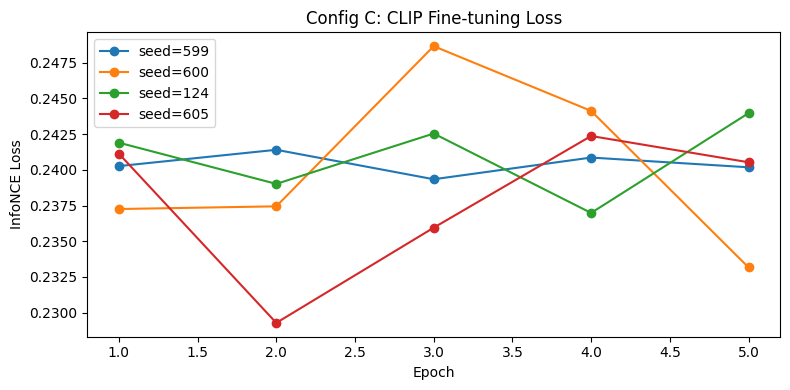

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
for seed, hist in histories.items():
    plt.plot(range(1, len(hist) + 1), hist, marker="o", label=f"seed={seed}")

plt.title("Config C: CLIP Fine-tuning Loss")
plt.xlabel("Epoch")
plt.ylabel("InfoNCE Loss")
if plt.gca().get_legend_handles_labels()[0]:
    plt.legend()
plt.tight_layout()
plt.savefig("ablation_C_loss_curve.png", dpi=150)
plt.show()
